## 🎯 Objetivo

Encontrar:
Quais clientes têm maior risco de churn e quais fatores # # influenciam isso?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set()

In [2]:
# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

#print("Path to dataset files:", path)


## Carregar dados

In [3]:
caminho_arquivo = r'I:\ESTUDO\PROJETOS\13-Analise_Churn\Bd-Telco-Customer-Churn.csv'

df = pd.read_csv(caminho_arquivo, low_memory=False)

### ETAPA 4 — Limpeza e Correção do Tipo de dados

In [4]:
# Remover espaços em branco (caso tenha)
df_analise = df.columns.str.strip()

# Remover nulos (caso tenha)
df_analise = df.dropna()

# Converter TotalCharges para númerico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

display(df_analise.info())
display(df_analise.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### ETAPA 5 — Métrica principal (CHURN)

In [5]:
# Calculando a taxa de quantos cancelaram ou não o serviço.
taxa_churn = round(df['Churn'].value_counts(normalize=True) * 100,2)
print(taxa_churn)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## ETAPA 6 - Análise Gráfica de:

<function matplotlib.pyplot.show(close=None, block=None)>

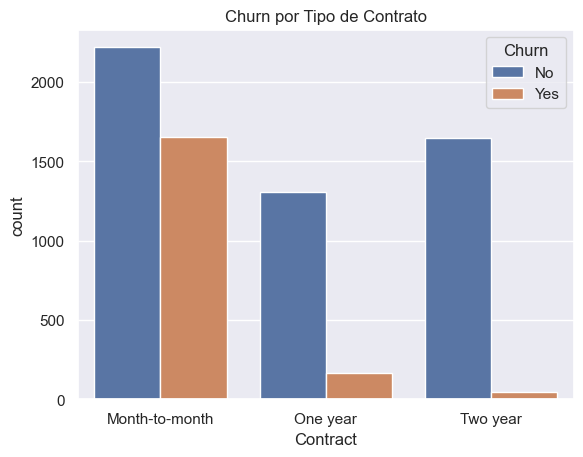

In [6]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn por Tipo de Contrato')
plt.show

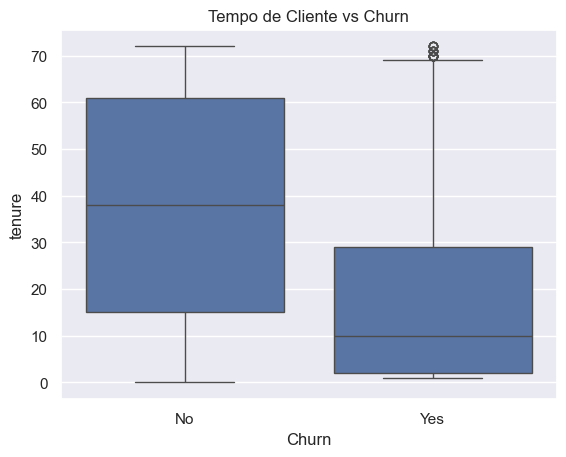

In [7]:
#2. Tempo de cliente (tenure)
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tempo de Cliente vs Churn')
plt.show()

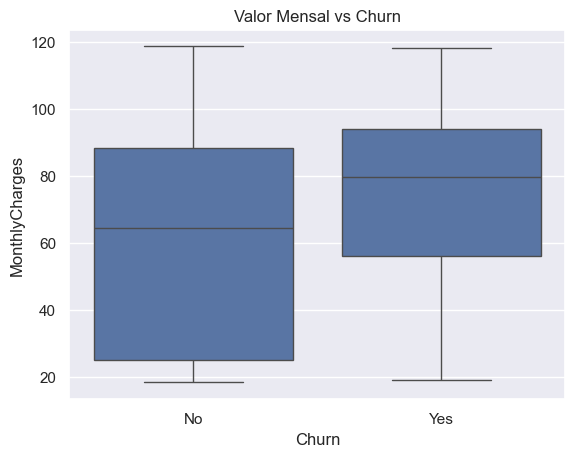

In [8]:
# 3.Valor Mensal
sns.boxplot(data=df_analise, x='Churn', y='MonthlyCharges')
plt.title('Valor Mensal vs Churn')
plt.show()

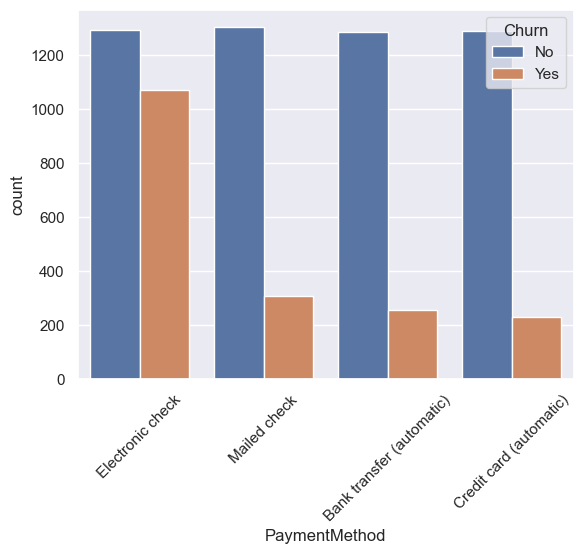

In [9]:
# 4.Método de pagamento
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.show()

## CONCLUSÃO (INSIGHTS)

## Principais Insights

- Clientes com contrato mensal apresentam maior taxa de churn
- Clientes com menor tempo de casa têm maior probabilidade de cancelamento
- Clientes com maiores cobranças mensais apresentam tendência a churn
- Estratégias de retenção devem focar nos primeiros meses do cliente